## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import re

## Import Datasets

In [2]:
sheets = pd.ExcelFile('Swap and Swaption Markets_Amended.xlsx').sheet_names
sheets

['LIBOR (legacy)', 'OIS (SOFR)', 'OIS (Term SOFR)', 'Swaption']

In [3]:
df_LIBOR = pd.read_excel('Swap and Swaption Markets_Amended.xlsx', sheet_name=sheets[0])
df_LIBOR;

Notes on LIBOR Rates on first inspection:
* Day Count Convention: 30/360
* Floating Rate: LIBOR 6M
* Floating Leg Frequency and Fixed Leg Frequency: Semi-Annual

In [4]:
df_LIBOR = df_LIBOR.dropna(axis=1)

In [5]:
def convert_tenor_to_numeric(series):
    num = series.str.slice(stop = -1).astype(int)
    freq = series.str.slice(start = -1)

    conditions = [freq.str.upper() == 'M', freq.str.upper() == 'Y']
    choices = [num * 30 / 360, num.astype(float)]

    return np.select(conditions, choices, default=np.nan)

In [6]:
df_LIBOR['Tenor_Year_Fraction'] = convert_tenor_to_numeric(df_LIBOR['Tenor'])
df_LIBOR

,Tenor,Product,Rate,Tenor_Year_Fraction
0,6m,LIBOR,0.0450,0.5
1,1y,IRS,0.0480,1.0
2,2y,IRS,0.0500,2.0
3,3y,IRS,0.0515,3.0
4,4y,IRS,0.0525,4.0
5,5y,IRS,0.0530,5.0
6,7y,IRS,0.0550,7.0
7,10y,IRS,0.0570,10.0
8,15y,IRS,0.0600,15.0
9,20y,IRS,0.0650,20.0


In [7]:
df_OIS = pd.read_excel('Swap and Swaption Markets_Amended.xlsx', sheet_name=sheets[1])
df_OIS;

Notes on OIS Rates on first inspection:
* Day Count Convention: 30/360
* Floating Rate: SOFR 1D
* Overnight Leg Frequency and Fixed Leg Frequency: Annual

In [8]:
df_OIS = df_OIS.dropna(axis = 1)
# df_OIS['Term'].str.split()[1]

In [9]:
def convert_tenor_to_numeric_OIS(series):
    parts = series.str.split()
    num = parts.str[0].astype(int)
    unit = parts.str[1]

    conditions = [unit == 'WK', unit == 'MO', unit == 'YR']
    choices = [num * (30/4) / 360, num * 30 / 360, num.astype(float)]

    return np.select(conditions, choices, default=np.nan)

In [10]:
df_OIS['Tenor_Year_Numeric'] = convert_tenor_to_numeric_OIS(df_OIS['Term'])
df_OIS['Market Rate'] = df_OIS['Market Rate'] / 100
df_OIS

,Term,Market Rate,Tenor_Year_Numeric
0,1 WK,0.036595,0.020833
1,2 WK,0.036580,0.041667
2,3 WK,0.036610,0.062500
3,1 MO,0.036701,0.083333
4,2 MO,0.036660,0.166667
5,3 MO,0.036595,0.250000
6,4 MO,0.036490,0.333333
7,5 MO,0.036351,0.416667
8,6 MO,0.036161,0.500000
9,7 MO,0.035945,0.583333


In [11]:
df_OIS_Term = pd.read_excel('Swap and Swaption Markets_Amended.xlsx', sheet_name=sheets[2])
# df_OIS_Term;

Notes on OIS Term Rates on first inspection:
* Day Count Convention: 30/360
* Floating Rate: SOFR 3M
* Overnight Leg Frequency and Fixed Leg Frequency: Annual

In [12]:
df_OIS_Term = df_OIS_Term.dropna(axis = 1)
df_OIS_Term['Tenor_Year_Numeric'] = convert_tenor_to_numeric(df_OIS_Term['Tenor'])
df_OIS_Term

,Tenor,Rate,Tenor_Year_Numeric
0,1Y,0.0465,1.0
1,2Y,0.0435,2.0
2,3Y,0.0415,3.0
3,4Y,0.0402,4.0
4,5Y,0.0395,5.0
5,6Y,0.0392,6.0
6,7Y,0.0390,7.0
7,8Y,0.0390,8.0
8,9Y,0.0391,9.0
9,10Y,0.0393,10.0


## Part 1: Bootstrapping Swap Curves

### A: OIS SOFR Rates

For OIS SOFR Rates, the rates are quoted at par swaps. Hence, we can expand from $PV_{float} = PV_{fixed}$ over 1 fixed payment

Since we are under 30/360 day count convention, we can take 1 week to be 7/360. This will underestimate term rates for weekends

$$
PV_{float} = \prod_{i-1}^{N} \left(1 + \Delta_{i-1} \cdot f_0(t_{i-1}, t_i) \right) = \prod_{i-1}^{N} \left(1 + \Delta_{i-1} \cdot \frac{1}{\Delta_{i-1}} \frac{D_0(0,t_{i-1}) - D_0(0,t_i)}{D_0(0,t_{i})} \right) = \frac{D_0(0, t_0)}{D_0(0,t_N)} = \frac{1}{D_0(0,t_N)}
$$
$$
PV_{fixed, <1y} = (1+\Delta S_0), PV_{fixed, >1y} = (1+S_0)^T
$$
$$
D_{0, <1y}(0,t_N) = \frac{1}{1+\Delta S_0}, \Delta=7/360 \\
D_{0, >1y}(0,t_N) = \frac{1}{(1+S_0)^T}

$$

In [13]:
df_OIS;

In [14]:
## Recreate the Tenor since we need T = [0,50]:

def calculate_ois_sofr_discount_factors(tenor_year, rates):

    discount_array = np.full(len(tenor_year), np.nan)

    # Bootstrap the Curve

    condition = (tenor_year <= 1.0)
    # choices = [1 / (1 + tenor_year*rates), 1 / (1 + rates)**tenor_year]

    discount_array = np.where(condition, 1 / (1 + tenor_year*rates), 1 / (1 + rates)**tenor_year)
    
    return pd.DataFrame(
                        {'Tenor_Year_Numeric': tenor_year,
                         'Market Rate': rates,
                         'Discount Factor': discount_array
                        }
                        )


In [15]:
ois_sofr_recalculated = calculate_ois_sofr_discount_factors(df_OIS['Tenor_Year_Numeric'], df_OIS['Market Rate'])
ois_sofr_recalculated

,Tenor_Year_Numeric,Market Rate,Discount Factor
0,0.020833,0.036595,0.999238
1,0.041667,0.036580,0.998478
2,0.062500,0.036610,0.997717
3,0.083333,0.036701,0.996951
4,0.166667,0.036660,0.993927
5,0.250000,0.036595,0.990934
6,0.333333,0.036490,0.987983
7,0.416667,0.036351,0.985080
8,0.500000,0.036161,0.982241
9,0.583333,0.035945,0.979462


<Axes: xlabel='Tenor_Year_Numeric'>

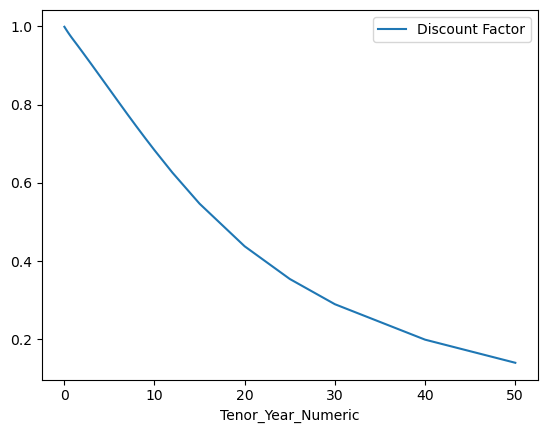

In [16]:
ois_sofr_recalculated.plot(x = 'Tenor_Year_Numeric', y = 'Discount Factor')

In [17]:
# ois_sofr_recalculated.columns

### B: LIBOR Bootstrapped Discount Factor

A Bootstrapped LIBOR with known zero rates follows the given formula:

$$
L_i(T_i, T_{i+1}) = \frac{1}{\Delta_{i}} \frac{D(0,T_i) - D(0,T_{i+1})}{D(0,T_{i+1})} 
$$

If the discount factor is for a zero rate less than 1 year, it is defined as:
$$
D(0,T) = \frac{1}{1 + \Delta_T\cdot{R_T}}
$$

For Interest Rate Swaps, the par swap rate is determined as (expanding from $PV_{float} = PV_{fixed} $):

$$
PV_{float} 
= \sum_{i=1}^{n} D(0,T_i)\left[\Delta_{i-1}L(T_{i-1}, T_i) \right] 
= \sum_{i=1}^{n} D(0,T_i) \left[\Delta_{i-1} \cdot \frac{1}{\Delta_{i-1}} \frac{D(0,T_{i-1}) - D(0,T_i)}{D(0,T_i)} \right] 
= \sum_{i=1}^{n} D(0,T_i) \left[ \frac{D(0,T_{i-1})- D(0,T_i)}{D(0,T_i)} \right] 
= [D(0,T_0) - D(0,T_n)]
$$
$$
PV_{fixed} = K \sum_{i=1}^{n} D(0,T_i) \times \Delta_{i-1} \newline
$$
$$
\\
\Rightarrow D(0,T_n) = \frac{ D(0,T_0) - K \sum_{i=1}^{n-1}\Delta_{i-1} D(0,T_i) }{1 + K \Delta_{n-1}}
$$

Where $\Delta = 0.5, D(0,T_0) = 1$


Therefore:
1. Calculate the Discount Factor of the initial LIBOR at 6m
2. Given the known LIBOR and the swap rate at the desired tenor T, calculate the discount rate at time T (Recall that floating and fixed legs are semi-annual coupons)
3. Continue to bootstrap until all the discount factors are known
4. Finally backcalculate the LIBOR discount factors

In [18]:
df_LIBOR

,Tenor,Product,Rate,Tenor_Year_Fraction
0,6m,LIBOR,0.0450,0.5
1,1y,IRS,0.0480,1.0
2,2y,IRS,0.0500,2.0
3,3y,IRS,0.0515,3.0
4,4y,IRS,0.0525,4.0
5,5y,IRS,0.0530,5.0
6,7y,IRS,0.0550,7.0
7,10y,IRS,0.0570,10.0
8,15y,IRS,0.0600,15.0
9,20y,IRS,0.0650,20.0


In [19]:
# def expand_irs_table(tenor_year, rate, frequency):

#     # tenor_year = tenor_year.to_numpy()
#     # rate = rate.to_numpy()

#     expanded_tenor_year = np.arange(start = tenor_year[0], stop= tenor_year[-1]+ frequency, step = frequency)
#     expanded_rate = np.full(len(expanded_tenor_year), np.nan)

#     # Populate the known rates
#     known_indices = np.searchsorted(expanded_tenor_year, tenor_year)
#     expanded_rate[known_indices] = rate
    
#     # Interpolate
#     known_mask = ~np.isnan(expanded_rate)
#     missing_mask = np.isnan(expanded_rate)

#     known_x = expanded_tenor_year[known_mask]
#     known_y = expanded_rate[known_mask]

#     expanded_rate_interp = expanded_rate.copy()

#     expanded_rate_interp[missing_mask] = np.interp(expanded_tenor_year[missing_mask], known_x, known_y)

#     return expanded_tenor_year, expanded_rate_interp
# # Recreate the Tenor since we need T = [0,30]:

# def calculate_libor_discount_factors(tenor_year, rates, frequency):

#     tenor_year = tenor_year.to_numpy()
#     rate = rates.to_numpy()

#     expanded_tenor_year_irs, expanded_rate_irs = expand_irs_table(tenor_year[1:], rate[1:], frequency)  # IRS starts from row index 1 onwards

#     expanded_tenor_year = np.append(tenor_year[0], expanded_tenor_year_irs)
#     expanded_rate = np.append(rate[0], expanded_rate_irs)
    
#     discount_array = np.full(len(expanded_tenor_year), np.nan)
#     discount_array[0] = 1/(1+frequency*rate[0])


#     # Bootstrap the Curve

#     for i in range(1, len(discount_array)):
#         discount_array[i] =\
#                             (
#                                     (1 - expanded_rate[i]*np.sum(frequency*discount_array[:i]))
#                                     /
#                                     (1 + expanded_rate[i]*frequency)
#                             )
#         # print(i)
        

#     return pd.DataFrame([expanded_tenor_year, expanded_rate, discount_array]).T


In [20]:
def calculate_libor_discount_factors(
    tenor_year: pd.Series,
    rates: pd.Series,
    frequency: float
) -> pd.DataFrame:
    """
    Bootstrap discount factors from a LIBOR rate followed by IRS rates.

    Parameters
    ----------
    tenor_year : tenor year fractions — first entry is LIBOR, rest are IRS
    rates      : corresponding rates
    frequency  : coupon frequency (1.0 = annual, 0.5 = semi-annual)

    Returns
    -------
    pd.DataFrame — columns: Tenor_Year_Fraction, Rate, DiscountFactor
    """
    tenor_year = np.asarray(tenor_year, dtype=float)
    rates      = np.asarray(rates,      dtype=float)

    # --- Step 1: Expand IRS rates onto a regular grid using pandas ---
    irs_curve  = pd.Series(rates[1:], index=tenor_year[1:])
    # print(irs_curve)
    
    full_index = np.arange(tenor_year[1], tenor_year[-1] + frequency, frequency)
    irs_curve  = irs_curve.reindex(full_index).interpolate(method='index')

    # print(full_index, irs_curve)

    # --- Step 2: Combine LIBOR anchor with full IRS curve ---
    full_tenors = np.concatenate([[tenor_year[0]], irs_curve.index.to_numpy()])
    full_rates  = np.concatenate([[rates[0]],       irs_curve.to_numpy()])

    # --- Step 3: Bootstrap discount factors ---
    dfs    = np.empty(len(full_tenors))
    dfs[0] = 1 / (1 + rates[0] * tenor_year[0])   # LIBOR — simple interest

    for i, r in enumerate(full_rates[1:], start=1):
        dfs[i] = (1 - r * frequency * dfs[:i].sum()) / (1 + r * frequency)

    return pd.DataFrame({
        'Tenor_Year_Numeric' : full_tenors,
        'Rate'                : full_rates,
        'DiscountFactor'      : dfs,
    })

In [21]:
libor_discount_factors = calculate_libor_discount_factors(df_LIBOR['Tenor_Year_Fraction'], df_LIBOR['Rate'], 0.5)
libor_discount_factors

,Tenor_Year_Numeric,Rate,DiscountFactor
0,0.5,0.045000,0.977995
1,1.0,0.048000,0.953641
2,1.5,0.049000,0.929893
3,2.0,0.050000,0.905816
4,2.5,0.050750,0.882022
5,3.0,0.051500,0.858181
6,3.5,0.052000,0.835091
7,4.0,0.052500,0.812186
8,4.5,0.052750,0.790444
9,5.0,0.053000,0.769070


### C: Term-SOFR Rates

With the data provided for term-SOFR market quotes, there is now complexity in the calculation for $PV_{float}$ due to the multi-curve nature of the framework <br>
If there is no accrual, i.e.: no $\Delta$

$$ 
L(T_{i-1}, T_i) D_0(0, T_i) = D_0(0,T_{i-1}) 
$$

The floating rate is the SOFR 3M rate



For OIS Term Rate, again expanding from $PV_{float} = PV_{fixed}$, given an annual payout on both the floating and fixed rate

$$
PV_{float} 
= \sum_{i=1}^{n} D_0(0,T_i) \left[\Delta_{i-1}L(t_{i-1}, t_i) \right] 
= \sum_{i=1}^{n} D_0(0,T_i) \left[\Delta_{i-1} \cdot \frac{1}{\Delta_{i-1}} \frac{D(0,T_{i-1}) - D(0,T_i)}{D(0,T_i)} \right] 
= \sum_{i=1}^{n} D_0(0,T_i) \left[ \frac{D(0,T_{i-1}) - D(0,T_i)}{D(0,T_i)} \right] \\
= \sum_{i=1}^{n-1} D_0(0,T_i) \left[ \frac{D(0,T_{i-1}) - D(0,T_{i})}{D(0,T_i)} \right] + D_{0}(0,T_n)\left[\frac{D(0,T_{n-1}) - D(0,T_{n})}{D(0,T_n)}  \right]
$$


$$
PV_{fixed, \ge1y} = K \sum_{i=1}^{n} D_0(0,T_i)
$$
$$
\therefore 
K \sum_{i=1}^{n} D_0(0,T_i) = \sum_{i=1}^{n-1} D_0(0,T_i) \left[ \frac{D(0,T_{i-1}) - D(0,T_{i})}{D(0,T_i)} \right] + D_{0}(0,T_n)\left[\frac{D(0,T_{n-1}) - D(0,T_{n})}{D(0,T_n)}  \right] \\

D_{0}(0,T_n)\left[\frac{D(0,T_{n-1}) - D(0,T_{n})}{D(0,T_n)}  \right] = K \sum_{i=1}^{n} D_0(0,T_i) - \sum_{i=1}^{n-1} D_0(0,T_i) \left[ \frac{D(0,T_{i-1}) - D(0,T_{i})}{D(0,T_i)} \right] = A \\
$$

$$
D(0,T_n) = \frac{D(T_{n-1})}{1+\frac{A}{D_0(0,T_n)}} 
$$

$ Where \ K \sum_{i=1}^{n} D_0(0,T_i) - \sum_{i=1}^{n-1} D_0(0,T_i) \left[ \frac{D(0,T_{i-1}) - D(0,T_{i})}{D(0,T_i)} \right] = A$

We can iteratively solve for $D(0,T_n)$ given the OIS SOFR rates


Alternatively, we bootstrap the forward rates directly. This looks computationally easier

$$
PV_{float} 
= \sum_{i=1}^{n} D_0(0,T_i) \left[\Delta_{i-1}L(t_{i-1}, t_i) \right]
= \sum_{i=1}^{n-1} D_0(0,T_i) \left[L(t_{i-1}, t_i) \right] + D_0(0,T_n) \left[L(t_{n-1}, t_n) \right], \Delta_{i-1} = 1
$$

$$
PV_{fixed, \ge1y} = K \sum_{i=1}^{n} \Delta_{i} D_0(0,T_i), \Delta_{i} = 1
$$

$$
\therefore
\sum_{i=1}^{n-1} D_0(0,T_i) \left[L(t_{i-1}, t_i) \right] + D_0(0,T_n) \left[L(t_{n-1}, t_n) \right] = K \sum_{i=1}^{n} D_0(0,T_i) \\
D_0(0,T_n) \left[L(t_{n-1}, t_n) \right] = K \sum_{i=1}^{n} D_0(0,T_i) - \sum_{i=1}^{n-1} D_0(0,T_i)\left[L(t_{i-1}, t_i) \right] \\
L(t_{n-1}, t_n) = \frac{1}{D_0(0,T_n)} \cdot \left[ K \sum_{i=1}^{n} D_0(0,T_i) - \sum_{i=1}^{n-1} D_0(0,T_i)L(t_{i-1}, t_i) \right]
$$

In [22]:
def extract_ois_values(df_OIS, tenor_year_series, start, end, multiple):
    ext = df_OIS.loc[(tenor_year_series <=30) & (tenor_year_series%multiple == 0)]
    ext.index = np.asarray(ext[tenor_year_series.name])
    ext = ext.reindex(np.arange(start+multiple, end+multiple, multiple))
    ext = ext.interpolate('index')
    return ext

In [23]:
## Extract OIS SOFR Rates with a multiple of 1

extracted_ois_values = extract_ois_values(ois_sofr_recalculated[['Tenor_Year_Numeric', 'Market Rate']], ois_sofr_recalculated['Tenor_Year_Numeric'], 0, 30, 1)
extracted_ois_discounts = calculate_ois_sofr_discount_factors(extracted_ois_values['Tenor_Year_Numeric'],extracted_ois_values['Market Rate'])
extracted_ois_discounts.head()

,Tenor_Year_Numeric,Market Rate,Discount Factor
1,1.0,0.034957,0.966224
2,2.0,0.034009,0.935300
3,3.0,0.034306,0.903758
4,4.0,0.034892,0.871806
5,5.0,0.035547,0.839750


In [24]:
def interpolate_tenors(df, tenor_series, rate_series, multiple):
    df.index = np.asarray(tenor_series)

    tenor_col_name = tenor_series.name
    rate_name = rate_series.name

    df = df.reindex(np.arange(0+multiple, 30+multiple, multiple)).reset_index(drop = True)

    ## Initial positions cannot be interpolated, so need to first put the first few values in before running the interpolation
    df[tenor_col_name] = df[tenor_col_name].fillna(df.index.to_series()*multiple+multiple)
    df.loc[df.index[0], rate_name] = df.loc[df.index[int((1/multiple) - 1)], rate_name] * multiple
    df = df.interpolate(method = 'index')


    return df

In [25]:
df_OIS_Term;

In [26]:
interpolated_ois_term = interpolate_tenors(df_OIS_Term[['Tenor_Year_Numeric', 'Rate']], df_OIS_Term['Tenor_Year_Numeric'], df_OIS_Term['Rate'], 1)

In [27]:
# display(interpolated_ois_term, extracted_ois_discounts)

$$
L(t_{n-1}, t_n) = \frac{1}{D_0(0,T_n)} \cdot \left[ K \sum_{i=1}^{n} D_0(0,T_i) - \sum_{i=1}^{n-1} D_0(0,T_i)L(t_{i-1}, t_i) \right]
$$

In [28]:
## Paid Annually

def bootstrap_ois_term_rates(tenors, ois_term_swap_rates, ois_discounts, term_name):
    
    ois_term_rates = pd.Series(np.zeros(len(tenors)))

    ## Bootstrap from the 2nd discount factor onwards, the first discount factor is the discount factor of the par swap rate

    for i, item in enumerate(tenors):

        if i == 0:
            ois_term_rates.iloc[i] = ois_term_swap_rates.iloc[i]

        else:
            
            A1 = ois_term_swap_rates.iloc[i] * np.sum(ois_discounts.iloc[:i])
            A2_series = ois_discounts*ois_term_swap_rates
            A2 = np.sum(A2_series.iloc[:i-1])

            # print(A1, A2, ois_term_rates.iloc[i], i)
            
            ois_term_rates.iloc[i] =\
            (
                (A1 - A2)
                /
                ois_discounts.iloc[i]
            )

    return pd.DataFrame(
                            {'Tenor_Year_Numeric': tenors,
                             term_name: ois_term_rates
                            }
                        )

In [29]:
# interpolated_ois_term, extracted_ois_discounts
ois_term_rates = bootstrap_ois_term_rates(interpolated_ois_term['Tenor_Year_Numeric'], interpolated_ois_term['Rate'], extracted_ois_discounts['Discount Factor'], 'OIS 3M Rates')
ois_term_rates.head()

,Tenor_Year_Numeric,OIS 3M Rates
0,1.0,0.046500
1,2.0,0.044938
2,3.0,0.087317
3,4.0,0.081144
4,5.0,0.076689


In [30]:
def convert_fwd_sofr_factors(tenor_series, discount_series):

    fwd_sofr_series = pd.Series(np.zeros(len(tenor_series)))

    for i, item in enumerate(fwd_sofr_series):
        if i == 0:
            fwd_sofr_series[i] = (1 - discount_series[i]) / (discount_series[i]*tenor_series[0])

        else:
            fwd_sofr_series[i] = (discount_series[i-1] - discount_series[i]) / (discount_series[i]*tenor_series[0])

    return fwd_sofr_series

In [31]:
libor_discount_factors['libor_rate'] =\
(
    convert_fwd_sofr_factors(libor_discount_factors['Tenor_Year_Numeric'], libor_discount_factors['DiscountFactor'])
)

In [32]:
libor_rates_unsecured =\
(
    libor_discount_factors[round(libor_discount_factors['Tenor_Year_Numeric']) == libor_discount_factors['Tenor_Year_Numeric']].drop(columns = 'Rate').reset_index(drop = True)
)

In [33]:
# display(interpolated_ois_term.columns, extracted_ois_discounts.columns)

In [34]:
libor_rates_unsecured

,Tenor_Year_Numeric,DiscountFactor,libor_rate
0,1.0,0.953641,0.051077
1,2.0,0.905816,0.053159
2,3.0,0.858181,0.055563
3,4.0,0.812186,0.056405
4,5.0,0.769070,0.055583
5,6.0,0.724972,0.060525
6,7.0,0.681790,0.062986
7,8.0,0.641660,0.062021
8,9.0,0.602865,0.063796
9,10.0,0.565408,0.065657


### Optional Part D: LIBOR rates under multi-curve framework

Since OIS Discount Factors are known, the LIBOR discount curve could be re-expressed using SOFR OIS discount factors

We can do a similar bootstrapping computation

$$
PV_{float} 
= \sum_{i=1}^{n} D_0(0,T_i) \left[\Delta_{i-1}L(t_{i-1}, t_i) \right]
=  D_0(0,T_n) \Delta_{n-1} L(t_{n-1}, t_n) + \sum_{i=1}^{n-1} D_0(0,T_i) \Delta_{i-1} L(t_{i-1}, t_i) , \Delta = 0.5
$$

$$
PV_{fixed, \ge1y} = K \sum_{i=1}^{n} \Delta_{i-1} \cdot D_0(0,T_i), \Delta = 0.5
$$

$$
\therefore
D_0(0,T_n) \Delta_{n-1} L(t_{n-1}, t_n) + \sum_{i=1}^{n-1} D_0(0,T_i) \Delta_{i-1} L(t_{i-1}, t_i) = K \sum_{i=1}^{n} \Delta_{i-1} \cdot D_0(0,T_i) \\
D_0(0,T_n) \left[L(t_{n-1}, t_n) \right] = K \sum_{i=1}^{n} D_0(0,T_i) - \sum_{i=1}^{n-1} D_0(0,T_i)\left[L(t_{i-1}, t_i) \right] \\
L(t_{n-1}, t_n) = \frac{1}{D_0(0,T_n)} \cdot \left[ K \sum_{i=1}^{n} D_0(0,T_i) - \sum_{i=1}^{n-1} D_0(0,T_i)L(t_{i-1}, t_i) \right]
$$

In [35]:
libor_discount_factors.head()

,Tenor_Year_Numeric,Rate,DiscountFactor,libor_rate
0,0.5,0.04500,0.977995,0.045000
1,1.0,0.04800,0.953641,0.051077
2,1.5,0.04900,0.929893,0.051077
3,2.0,0.05000,0.905816,0.053159
4,2.5,0.05075,0.882022,0.053953


In [36]:
extracted_ois_values_half_year = extract_ois_values(ois_sofr_recalculated[['Tenor_Year_Numeric', 'Market Rate']], ois_sofr_recalculated['Tenor_Year_Numeric'], 0, 30, 0.5)
extracted_ois_discounts_half_year = calculate_ois_sofr_discount_factors(extracted_ois_values_half_year['Tenor_Year_Numeric'],extracted_ois_values_half_year['Market Rate']).reset_index(drop = True)
extracted_ois_discounts_half_year.tail()

,Tenor_Year_Numeric,Market Rate,Discount Factor
55,28.0,0.042279,0.313652
56,28.5,0.042257,0.307406
57,29.0,0.042236,0.301289
58,29.5,0.042214,0.295301
59,30.0,0.042193,0.289438


In [37]:
libor_multicurve_rates = bootstrap_ois_term_rates(extracted_ois_discounts_half_year['Tenor_Year_Numeric'], libor_discount_factors['Rate'], extracted_ois_discounts_half_year['Discount Factor'], 'libor_multicurve_rates')
libor_multicurve_rates.head()

,Tenor_Year_Numeric,libor_multicurve_rates
0,0.5,0.045000
1,1.0,0.048796
2,1.5,0.053920
3,2.0,0.058153
4,2.5,0.062467


### Output

<Axes: xlabel='Tenor_Year_Numeric'>

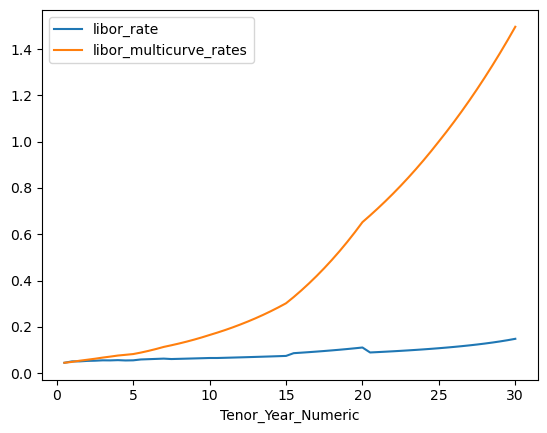

In [38]:
pd.merge(libor_discount_factors, libor_multicurve_rates).plot(x = 'Tenor_Year_Numeric', y = ['libor_rate', 'libor_multicurve_rates'])

In [39]:
# pd.merge(libor_multicurve_rates, ois_term_rates).plot(x = 'Tenor_Year_Numeric', y = ['libor_multicurve_rates', 'OIS 3M Rates'])

<Axes: xlabel='Tenor_Year_Numeric'>

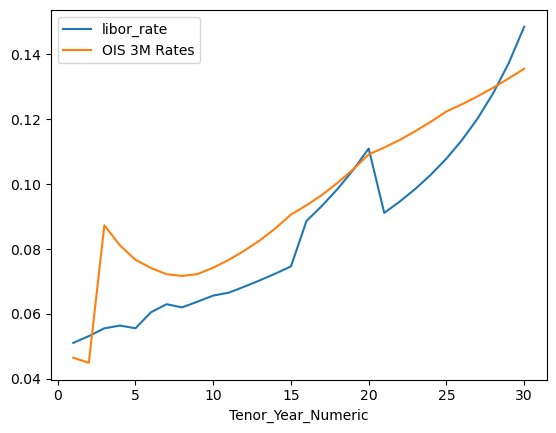

In [40]:
pd.merge(libor_rates_unsecured, ois_term_rates).plot(x = 'Tenor_Year_Numeric', y = ['libor_rate', 'OIS 3M Rates'])

<Axes: xlabel='Tenor_Year_Numeric'>

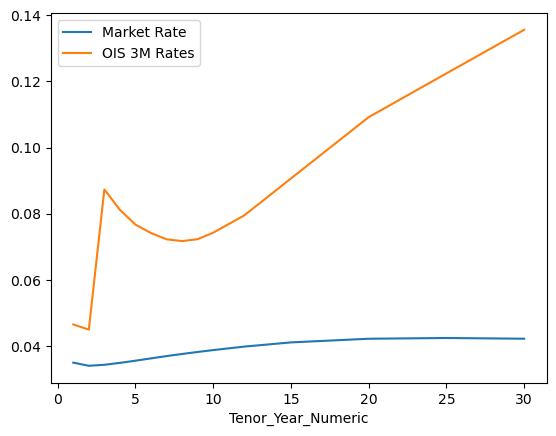

In [41]:
pd.merge(ois_sofr_recalculated, ois_term_rates).plot(x = 'Tenor_Year_Numeric', y = ['Market Rate', 'OIS 3M Rates'])

In [42]:
## Output to Files

libor_discount_factors.to_csv('libor_discount_factors.csv')
ois_term_rates.to_csv('ois_term_rates.csv')
ois_sofr_recalculated.to_csv('ois_sofr_recalculated.csv')
extracted_ois_discounts_half_year.to_csv('ois_sofr_discounted_factors.csv')